# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

In [2]:
# ============================================================
# 1. Imports + GPU / mixed-precision setup
# ============================================================
import os
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from IPython.display import display
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", gpus)

# Let GPU memory grow on demand instead of grabbing all VRAM up front.
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("memory_growth:", e)

# Mixed precision only helps on GPU; stay float32 on CPU.
if gpus:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision policy:", tf.keras.mixed_precision.global_policy().name)
else:
    print("No GPU -> staying in float32.")

def free_memory():
    """Clear the Keras/TF graph and reclaim Python memory between models."""
    tf.keras.backend.clear_session()
    gc.collect()

TensorFlow: 2.21.0
GPU available: []
No GPU -> staying in float32.


In [3]:
# ============================================================
# 2. Download dataset (set downloadData=False if already present)
# ============================================================

import urllib.request
import zipfile
import shutil

downloadData = False

if downloadData:
    for name in ["cell_images", "__MACOSX"]:
        if os.path.exists(name):
            shutil.rmtree(name)
    if os.path.exists("cell_images.zip"):
        os.remove("cell_images.zip")

    url = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"
    print("Downloading dataset (this may take a few minutes)...")

    def _progress(block, block_size, total):
        downloaded = block * block_size
        if total > 0:
            pct = min(downloaded / total * 100, 100)
            print(f"\r  {pct:.1f}%  ({downloaded // 1_000_000} MB / {total // 1_000_000} MB)", end="")

    urllib.request.urlretrieve(url, "cell_images.zip", reporthook=_progress)
    print("\nUnzipping...")
    with zipfile.ZipFile("cell_images.zip", "r") as zf:
        zf.extractall(".")
    print("Done. Contents:", os.listdir("."))
else:
    print("Skipping download. Make sure the cell_images folder exists.")

Skipping download. Make sure the cell_images folder exists.


In [4]:
# ============================================================
# 3. Global configuration (shared by ALL models)
# ============================================================

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INFER_BATCH = 64
SCRATCH_IMG_SIZE = (96, 96)
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

# Auto-detect dataset location (Colab vs local) -> resolves to the local
# "cell_images" folder that cell 3 downloads next to this notebook.
_candidates = [
    "/content/cell_images/cell_images",
    "/content/cell_images",
    "cell_images/cell_images",
    "cell_images",
]
DATA_DIR = next(
    (d for d in _candidates
     if os.path.isdir(os.path.join(d, "Parasitized"))),
    "cell_images",
)

print("DATA_DIR:", DATA_DIR)
print("Folders:", os.listdir(DATA_DIR))

MAX_EXPERIMENTS_TO_RUN = 7

ROOT_RESULTS = "results_all_models"          # relative -> lands next to the notebook
os.makedirs(ROOT_RESULTS, exist_ok=True)

FEATURE_CACHE_DIR = "feature_cache"          # relative -> next to the notebook
os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)

USE_FEATURE_CACHE = True

DATA_DIR: cell_images
Folders: ['Parasitized', 'Uninfected']


In [5]:
# ============================================================
# 4. Load + split ONCE  (RAM-SAFE: shuffle file paths, not decoded images)
# ============================================================

import glob

parasitized = sorted(glob.glob(os.path.join(DATA_DIR, "Parasitized", "*.png")))
uninfected  = sorted(glob.glob(os.path.join(DATA_DIR, "Uninfected",  "*.png")))
print(f"Parasitized files: {len(parasitized)}  Uninfected files: {len(uninfected)}")

all_paths  = parasitized + uninfected
all_labels = [1] * len(parasitized) + [0] * len(uninfected)

POSITIVE_LABEL = "Parasitized (infected)"
NEGATIVE_LABEL = "Uninfected (healthy)"
class_names = [NEGATIVE_LABEL, POSITIVE_LABEL]

dataset_size = len(all_paths)
print("Total images:", dataset_size)

rng = np.random.default_rng(SEED)
perm = rng.permutation(dataset_size)
all_paths  = [all_paths[i]  for i in perm]
all_labels = [all_labels[i] for i in perm]

train_size = int(0.70 * dataset_size)
val_size   = int(0.15 * dataset_size)
test_size  = dataset_size - train_size - val_size
print(f"train={train_size}  val={val_size}  test={test_size}")
print("Positive class (label=1):", POSITIVE_LABEL)

def _load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, tf.cast(label, tf.float32)

def _paths_to_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    return ds.map(_load_image, num_parallel_calls=AUTOTUNE)

train_raw = _paths_to_ds(all_paths[:train_size],
                         all_labels[:train_size])
val_raw   = _paths_to_ds(all_paths[train_size:train_size + val_size],
                         all_labels[train_size:train_size + val_size])
test_raw  = _paths_to_ds(all_paths[train_size + val_size:],
                         all_labels[train_size + val_size:])

print("Raw splits ready (lazy, RAM-safe).")

Parasitized files: 13779  Uninfected files: 13779
Total images: 27558
train=19290  val=4133  test=4135
Positive class (label=1): Parasitized (infected)
Raw splits ready (lazy, RAM-safe).


In [6]:
# ============================================================
# 5. Batch helpers  (RAM-SAFE: no .cache() anywhere)
# ============================================================

def make_ds(ds, batch_size=BATCH_SIZE, shuffle=False, resize_to=None):
    if resize_to is not None:
        ds = ds.map(lambda x, y: (tf.image.resize(x, resize_to), y),
                    num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(train_raw, BATCH_SIZE, shuffle=True)
val_ds   = make_ds(val_raw,   BATCH_SIZE)
test_ds  = make_ds(test_raw,  BATCH_SIZE)

for images, labels in train_ds.take(1):
    print("batch images:", images.shape, "labels:", labels.shape)
    print("pixel range:", float(tf.reduce_min(images)), "to",
          float(tf.reduce_max(images)))

batch images: (32, 224, 224, 3) labels: (32,)
pixel range: 0.0 to 234.62673950195312


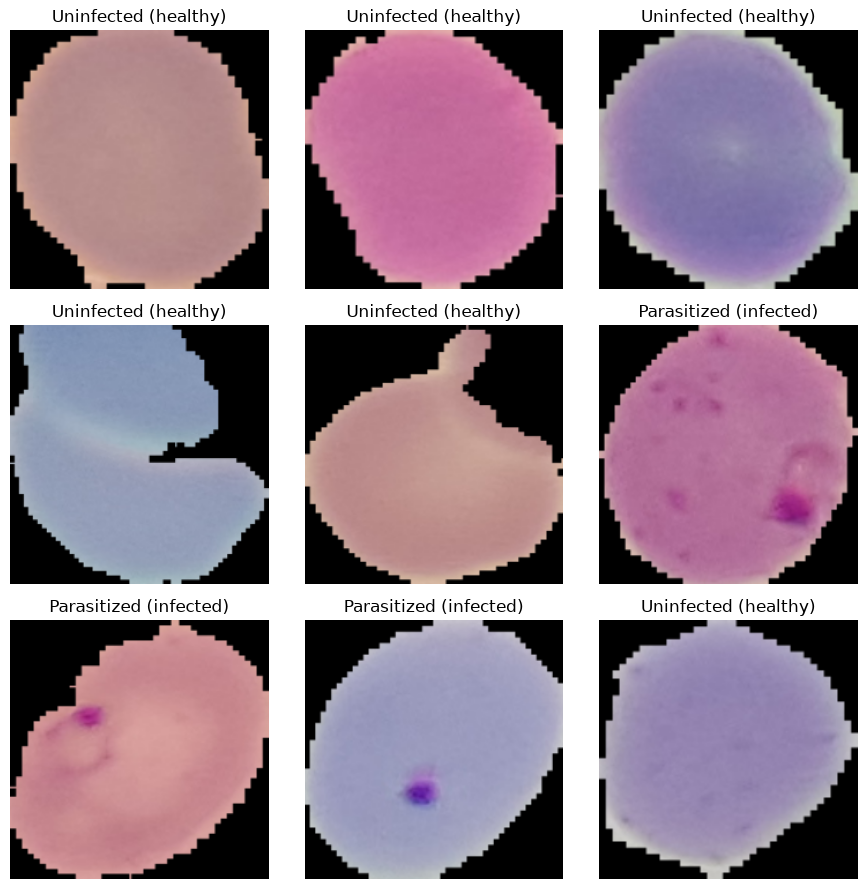

In [7]:
# ============================================================
# 6. Peek at a few images
# ============================================================

plt.figure(figsize=(9, 9))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis("off")
plt.tight_layout(); plt.show()

In [8]:
# ============================================================
# 7. Shared metric + plotting utilities
# ============================================================

def safe_name(text):
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in text)

def collect_predictions(model, dataset):
    """One batched predict over the whole dataset (no per-batch Python loop)."""
    y_prob = model.predict(dataset, verbose=0).reshape(-1).astype(np.float32)
    y_true = np.concatenate(
        [by.numpy().reshape(-1) for _, by in dataset]).astype(int)
    y_pred = (y_prob >= 0.5).astype(int)
    return y_true, y_prob, y_pred

def collect_predictions_array(model, X, y):
    """Predict directly on a cached feature array — skips tf.data rebuild."""
    y_prob = model.predict(X, verbose=0, batch_size=256).reshape(-1).astype(np.float32)
    y_true = np.asarray(y).reshape(-1).astype(int)
    return y_true, y_prob, (y_prob >= 0.5).astype(int)

def compute_metrics(y_true, y_prob, y_pred):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1_score":  f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_prob),
    }

def plot_learning_curves(history, model_name, exp_name, out_dir):
    h = history.history
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h.get("accuracy", []), label="train")
    plt.plot(h.get("val_accuracy", []), label="val")
    plt.title(f"{model_name}\n{exp_name} accuracy")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(h.get("loss", []), label="train")
    plt.plot(h.get("val_loss", []), label="val")
    plt.title(f"{exp_name} loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{safe_name(exp_name)}_curves.png"),
                dpi=140, bbox_inches="tight")
    plt.show()

def plot_confusion(y_true, y_pred, model_name, exp_name, out_dir):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"{model_name} - {exp_name}\nConfusion Matrix")
    plt.savefig(os.path.join(out_dir, f"{safe_name(exp_name)}_confusion.png"),
                dpi=140, bbox_inches="tight")
    plt.show()

def plot_roc(y_true, y_prob, model_name, exp_name, out_dir):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6, 4.5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], "--", label="random")
    plt.title(f"{model_name} - {exp_name}\nROC")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (recall)")
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(out_dir, f"{safe_name(exp_name)}_roc.png"),
                dpi=140, bbox_inches="tight")
    plt.show()

In [9]:
# ============================================================
# 8. Training runners (two paths: full-image and cached-feature)
# ============================================================

def make_callbacks(out_dir, exp_name, patience=3, checkpoint=True):
    cbs = [tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience,
        min_delta=1e-3, restore_best_weights=True)]
    if checkpoint:
        cbs.append(tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(out_dir, f"{safe_name(exp_name)}_best.keras"),
            monitor="val_loss", save_best_only=True))
    return cbs

def finalize_experiment(model, history, test_eval_ds, model_name,
                        exp_name, config, out_dir, extra=None):
    """predict on test ds, compute metrics, draw plots."""
    y_true, y_prob, y_pred = collect_predictions(model, test_eval_ds)
    return _finalize_common(y_true, y_prob, y_pred, history, model_name,
                            exp_name, config, out_dir, extra)

def finalize_experiment_array(model, history, X_test, y_test, model_name,
                              exp_name, config, out_dir, extra=None):
    """predict on the feature array directly."""
    y_true, y_prob, y_pred = collect_predictions_array(model, X_test, y_test)
    return _finalize_common(y_true, y_prob, y_pred, history, model_name,
                            exp_name, config, out_dir, extra)

def _finalize_common(y_true, y_prob, y_pred, history, model_name,
                     exp_name, config, out_dir, extra):
    metrics = compute_metrics(y_true, y_prob, y_pred)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred,
          target_names=class_names, zero_division=0))
    plot_learning_curves(history, model_name, exp_name, out_dir)
    plot_confusion(y_true, y_pred, model_name, exp_name, out_dir)
    plot_roc(y_true, y_prob, model_name, exp_name, out_dir)
    row = {
        "model": model_name,
        "experiment": exp_name,
        "learning_rate": config.get("lr"),
        "batch_size": config.get("batch_size", BATCH_SIZE),
        "dropout": config.get("dropout"),
        "augmentation": config.get("augmentation"),
        "fine_tune": config.get("fine_tune", False),
        **metrics,
    }
    if extra:
        row.update(extra)
    return row

In [10]:
# ============================================================
# 9. Transfer-learning helpers: backbone registry + feature extraction
# ============================================================

TRANSFER_BACKBONES = {
    "vgg16_transfer": (
        tf.keras.applications.VGG16,
        tf.keras.applications.vgg16.preprocess_input,
        "vgg16_base"),
    "resnet50_transfer": (
        tf.keras.applications.ResNet50,
        tf.keras.applications.resnet50.preprocess_input,
        "resnet50_base"),
    "mobilenetv2_transfer": (
        tf.keras.applications.MobileNetV2,
        tf.keras.applications.mobilenet_v2.preprocess_input,
        "mobilenetv2_base"),
    "efficientnetb0_transfer": (
        tf.keras.applications.EfficientNetB0,
        tf.keras.applications.efficientnet.preprocess_input,
        "efficientnetb0_base"),
}

def build_backbone(model_name):
    ctor, preprocess, base_name = TRANSFER_BACKBONES[model_name]
    base = ctor(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    base._name = base_name
    return base, preprocess, base_name

def _extract_split_to_memmap(feat_model, raw_split, n_items, feat_dim, x_path):
    X = np.memmap(x_path, dtype="float32", mode="w+", shape=(n_items, feat_dim))
    y = np.zeros((n_items,), dtype="float32")
    ds = raw_split.batch(INFER_BATCH).prefetch(AUTOTUNE)
    i = 0
    for bx, by in ds:
        feats = feat_model(bx, training=False).numpy()
        b = feats.shape[0]
        X[i:i+b] = feats
        y[i:i+b] = by.numpy().reshape(-1)
        i += b
    X.flush()
    return X, y

def extract_features(model_name):
    meta_path = os.path.join(FEATURE_CACHE_DIR, f"{model_name}_meta.json")
    x_paths = {s: os.path.join(FEATURE_CACHE_DIR, f"{model_name}_{s}_X.dat")
               for s in ["tr", "va", "te"]}
    y_paths = {s: os.path.join(FEATURE_CACHE_DIR, f"{model_name}_{s}_y.npy")
               for s in ["tr", "va", "te"]}

    if (USE_FEATURE_CACHE and os.path.exists(meta_path)
            and all(os.path.exists(p) for p in x_paths.values())
            and all(os.path.exists(p) for p in y_paths.values())):
        print(f"  reopening cached feature memmaps for {model_name} (no GPU)...")
        meta = json.load(open(meta_path))
        fd = meta["feat_dim"]; ns = meta["sizes"]
        Xtr = np.memmap(x_paths["tr"], dtype="float32", mode="r", shape=(ns["tr"], fd))
        Xva = np.memmap(x_paths["va"], dtype="float32", mode="r", shape=(ns["va"], fd))
        Xte = np.memmap(x_paths["te"], dtype="float32", mode="r", shape=(ns["te"], fd))
        ytr = np.load(y_paths["tr"]); yva = np.load(y_paths["va"]); yte = np.load(y_paths["te"])
        return (Xtr, ytr), (Xva, yva), (Xte, yte), fd

    base, preprocess, _ = build_backbone(model_name)
    inp = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess(inp)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    feat_model = tf.keras.Model(inp, x)
    feat_dim = feat_model.output_shape[-1]

    print(f"  extracting features for {model_name} (single pass, frozen base)...")
    ntr, nva, nte = train_size, val_size, test_size
    print(f"  feature dim = {feat_dim}; sizes tr/va/te = {ntr}/{nva}/{nte}")

    Xtr, ytr = _extract_split_to_memmap(feat_model, train_raw, ntr, feat_dim, x_paths["tr"])
    print("    train features done")
    Xva, yva = _extract_split_to_memmap(feat_model, val_raw, nva, feat_dim, x_paths["va"])
    print("    val features done")
    Xte, yte = _extract_split_to_memmap(feat_model, test_raw, nte, feat_dim, x_paths["te"])
    print("    test features done")

    if USE_FEATURE_CACHE:
        np.save(y_paths["tr"], ytr); np.save(y_paths["va"], yva); np.save(y_paths["te"], yte)
        json.dump({"feat_dim": int(feat_dim),
                   "sizes": {"tr": int(ntr), "va": int(nva), "te": int(nte)}},
                  open(meta_path, "w"))
        print(f"  cached feature memmaps -> {FEATURE_CACHE_DIR}")

    del feat_model, base
    free_memory()
    return (Xtr, ytr), (Xva, yva), (Xte, yte), feat_dim

def build_head(feat_dim, config):
    """Tiny classifier trained on pre-extracted features."""
    dropout = config.get("dropout", 0.4)
    dense_units = config.get("dense_units", 256)
    lr = config.get("lr", 1e-3)

    inp = tf.keras.Input(shape=(feat_dim,))
    x = tf.keras.layers.Dense(dense_units, activation="relu")(inp)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.AUC(name="auc")])
    return model

def memmap_dataset(X, y, batch_size, shuffle=False):
    """Stream a feature memmap in mini-batches so Keras never copies the whole
    array into RAM."""
    n = X.shape[0]; fd = X.shape[1]
    def gen():
        order = np.arange(n)
        if shuffle:
            np.random.default_rng(SEED).shuffle(order)
        for s in range(0, n, batch_size):
            sel = np.sort(order[s:s+batch_size])
            yield np.asarray(X[sel]), y[sel]
    sig = (tf.TensorSpec(shape=(None, fd), dtype=tf.float32),
           tf.TensorSpec(shape=(None,), dtype=tf.float32))
    return tf.data.Dataset.from_generator(gen, output_signature=sig).prefetch(AUTOTUNE)

def predict_features_memmap(model, X, batch=256):
    """Predict in chunks straight off the memmap; no full-array copy."""
    probs = []
    for s in range(0, X.shape[0], batch):
        probs.append(model.predict(np.asarray(X[s:s+batch]), verbose=0).reshape(-1))
    return np.concatenate(probs).astype(np.float32)

In [11]:
# ============================================================
# 10. Full fine-tuning model (only for Exp7 of transfer models)
# ============================================================

def build_finetune_model(model_name, config):
    base, preprocess, base_name = build_backbone(model_name)
    dropout = config.get("dropout", 0.4)
    dense_units = config.get("dense_units", 256)
    lr = config.get("lr", 1e-4)
    augmentation = config.get("augmentation", True)

    inp = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = inp
    if augmentation:
        x = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.05),
        ], name="data_augmentation")(x)
    x = preprocess(x)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    model = tf.keras.Model(inp, out, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.AUC(name="auc")])
    return model, base, base_name

In [12]:
# ============================================================
# 11. Baseline + Advanced CNN builders
# ============================================================

def build_baseline(config):
    in_shape = config.get("input_size", SCRATCH_IMG_SIZE) + (3,)
    augmentation = config.get("augmentation", False)
    dropout = config.get("dropout", 0.3)
    lr = config.get("lr", 1e-3)
    dense_units = config.get("dense_units", 128)

    inputs = tf.keras.Input(shape=in_shape)
    x = tf.keras.layers.Rescaling(1./255)(inputs)
    if augmentation:
        x = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.05),
            tf.keras.layers.RandomZoom(0.10),
        ], name="data_augmentation")(x)
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    model = tf.keras.Model(inputs, out, name="baseline_cnn")
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy",
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           tf.keras.metrics.AUC(name="auc")])
    return model

def _conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    return x

def build_advanced(config):
    in_shape = config.get("input_size", SCRATCH_IMG_SIZE) + (3,)
    augmentation = config.get("augmentation", True)
    dropout = config.get("dropout", 0.5)
    lr = config.get("lr", 1e-3)
    dense_units = config.get("dense_units", 256)
    filters = config.get("filters", [32, 64, 128, 256])

    inputs = tf.keras.Input(shape=in_shape)
    x = tf.keras.layers.Rescaling(1./255)(inputs)
    if augmentation:
        x = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.08),
            tf.keras.layers.RandomZoom(0.15),
            tf.keras.layers.RandomContrast(0.10),
        ], name="data_augmentation")(x)
    for f in filters:
        x = _conv_block(x, f)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    model = tf.keras.Model(inputs, out, name="advanced_cnn")
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy",
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           tf.keras.metrics.AUC(name="auc")])
    return model

SCRATCH_BUILDERS = {
    "baseline_cnn": build_baseline,
    "advanced_cnn": build_advanced,
}

In [13]:
# ============================================================
# 12. Experiment configs for every model (7 each)
# ============================================================

ALL_EXPERIMENTS = {
 "baseline_cnn": [
    {"name":"Exp1_default_baseline","lr":1e-3,"batch_size":32,"dropout":0.30,"dense_units":128,"augmentation":False,"epochs":10},
    {"name":"Exp2_lower_learning_rate","lr":1e-4,"batch_size":32,"dropout":0.30,"dense_units":128,"augmentation":False,"epochs":10},
    {"name":"Exp3_higher_dropout","lr":1e-3,"batch_size":32,"dropout":0.50,"dense_units":128,"augmentation":False,"epochs":10},
    {"name":"Exp4_with_data_augmentation","lr":1e-3,"batch_size":32,"dropout":0.30,"dense_units":128,"augmentation":True,"epochs":10},
    {"name":"Exp5_smaller_batch_size","lr":1e-3,"batch_size":16,"dropout":0.30,"dense_units":128,"augmentation":False,"epochs":10},
    {"name":"Exp6_larger_dense_layer","lr":1e-3,"batch_size":32,"dropout":0.30,"dense_units":256,"augmentation":False,"epochs":10},
    {"name":"Exp7_combined_aug_dropout","lr":1e-4,"batch_size":32,"dropout":0.50,"dense_units":256,"augmentation":True,"epochs":12},
 ],
 "advanced_cnn": [
    {"name":"Exp1_advanced_default","lr":1e-3,"batch_size":32,"dropout":0.50,"dense_units":256,"filters":[32,64,128,256],"augmentation":True,"epochs":12},
    {"name":"Exp2_lower_learning_rate","lr":1e-4,"batch_size":32,"dropout":0.50,"dense_units":256,"filters":[32,64,128,256],"augmentation":True,"epochs":12},
    {"name":"Exp3_less_dropout","lr":1e-3,"batch_size":32,"dropout":0.30,"dense_units":256,"filters":[32,64,128,256],"augmentation":True,"epochs":12},
    {"name":"Exp4_no_augmentation","lr":1e-3,"batch_size":32,"dropout":0.50,"dense_units":256,"filters":[32,64,128,256],"augmentation":False,"epochs":12},
    {"name":"Exp5_smaller_batch_size","lr":1e-3,"batch_size":16,"dropout":0.50,"dense_units":256,"filters":[32,64,128,256],"augmentation":True,"epochs":12},
    {"name":"Exp6_deeper_filters","lr":1e-4,"batch_size":32,"dropout":0.50,"dense_units":256,"filters":[32,64,128,256,512],"augmentation":True,"epochs":14},
    {"name":"Exp7_smaller_model_regularized","lr":1e-4,"batch_size":32,"dropout":0.60,"dense_units":128,"filters":[32,64,128],"augmentation":True,"epochs":14},
 ],
}

# All 4 transfer models share the same 7-experiment recipe (only base differs)
def _transfer_experiments(base_name):
    return [
        {"name":"Exp1_feature_extraction_default","lr":1e-3,"batch_size":32,"dropout":0.40,"dense_units":256,"augmentation":True,"epochs":10,"base_layer_name":base_name},
        {"name":"Exp2_lower_learning_rate","lr":1e-4,"batch_size":32,"dropout":0.40,"dense_units":256,"augmentation":True,"epochs":10,"base_layer_name":base_name},
        {"name":"Exp3_higher_dropout","lr":1e-3,"batch_size":32,"dropout":0.60,"dense_units":256,"augmentation":True,"epochs":10,"base_layer_name":base_name},
        {"name":"Exp4_no_augmentation","lr":1e-3,"batch_size":32,"dropout":0.40,"dense_units":256,"augmentation":False,"epochs":10,"base_layer_name":base_name},
        {"name":"Exp5_smaller_batch_size","lr":1e-3,"batch_size":16,"dropout":0.40,"dense_units":256,"augmentation":True,"epochs":10,"base_layer_name":base_name},
        {"name":"Exp6_smaller_classifier","lr":1e-4,"batch_size":32,"dropout":0.30,"dense_units":128,"augmentation":True,"epochs":10,"base_layer_name":base_name},
        {"name":"Exp7_fine_tune_top_layers","lr":1e-4,"batch_size":32,"dropout":0.40,"dense_units":256,"augmentation":True,"epochs":8,"fine_tune":True,"fine_tune_epochs":6,"fine_tune_lr":1e-5,"fine_tune_last_n":20,"base_layer_name":base_name},
    ]

for mname, (_, _, bname) in TRANSFER_BACKBONES.items():
    ALL_EXPERIMENTS[mname] = _transfer_experiments(bname)


for k, v in ALL_EXPERIMENTS.items():
    print(f"{k}: {len(v)} experiments")

baseline_cnn: 7 experiments
advanced_cnn: 7 experiments
vgg16_transfer: 7 experiments
resnet50_transfer: 7 experiments
mobilenetv2_transfer: 7 experiments
efficientnetb0_transfer: 7 experiments


In [14]:
# ============================================================
# 13. Per-model runner — scratch models (baseline, advanced)
# ============================================================

def run_scratch_model(model_name):
    out_dir = os.path.join(ROOT_RESULTS, model_name)
    os.makedirs(out_dir, exist_ok=True)

    done_csv = os.path.join(out_dir, f"{model_name}_results.csv")
    if os.path.exists(done_csv):
        print(f"  {model_name} already done — loading CSV, skipping compute.")
        return pd.read_csv(done_csv)

    builder = SCRATCH_BUILDERS[model_name]
    rows = []
    partial_csv = os.path.join(out_dir, f"{model_name}_partial.csv")

    for config in ALL_EXPERIMENTS[model_name][:MAX_EXPERIMENTS_TO_RUN]:
        exp_name = config["name"]
        print("\n" + "=" * 80)
        print(f"[{model_name}] {exp_name}")
        print(config)
        print("=" * 80)

        bs = config.get("batch_size", BATCH_SIZE)
        tr = make_ds(train_raw, bs, shuffle=True, resize_to=SCRATCH_IMG_SIZE)
        va = make_ds(val_raw,   bs,               resize_to=SCRATCH_IMG_SIZE)
        te = make_ds(test_raw,  bs,               resize_to=SCRATCH_IMG_SIZE)

        free_memory()
        model = builder(config)
        history = model.fit(tr, validation_data=va,
                            epochs=config.get("epochs", 10),
                            callbacks=make_callbacks(out_dir, exp_name),
                            verbose=2)
        row = finalize_experiment(model, history, te, model_name,
                                  exp_name, config, out_dir)
        rows.append(row)
        pd.DataFrame(rows).to_csv(partial_csv, index=False)

        del model
        free_memory()

    df = pd.DataFrame(rows)
    df.to_csv(done_csv, index=False)
    return df

# 14. Per-model runner — transfer models (cached features + fine-tune)

In [15]:
# ============================================================
# 14. Per-model runner — transfer models (cached features + fine-tune)
# ============================================================

def run_transfer_model(model_name):
    out_dir = os.path.join(ROOT_RESULTS, model_name)
    os.makedirs(out_dir, exist_ok=True)

    done_csv = os.path.join(out_dir, f"{model_name}_results.csv")
    if os.path.exists(done_csv):
        print(f"  {model_name} already done — loading CSV, skipping compute.")
        return pd.read_csv(done_csv)

    rows = []
    partial_csv = os.path.join(out_dir, f"{model_name}_partial.csv")

    (Xtr, ytr), (Xva, yva), (Xte, yte), feat_dim = extract_features(model_name)

    for config in ALL_EXPERIMENTS[model_name][:MAX_EXPERIMENTS_TO_RUN]:
        exp_name = config["name"]
        print("\n" + "=" * 80)
        print(f"[{model_name}] {exp_name}")
        print(config)
        print("=" * 80)
        bs = config.get("batch_size", BATCH_SIZE)

        if not config.get("fine_tune", False):
            free_memory()
            head = build_head(feat_dim, config)
            train_head = memmap_dataset(Xtr, ytr, bs, shuffle=True)
            val_head   = memmap_dataset(Xva, yva, bs)
            history = head.fit(
                train_head, validation_data=val_head,
                epochs=config.get("epochs", 10),
                callbacks=make_callbacks(out_dir, exp_name, checkpoint=False),
                verbose=2)
            y_prob = predict_features_memmap(head, Xte)
            y_true = np.asarray(yte).reshape(-1).astype(int)
            y_pred = (y_prob >= 0.5).astype(int)
            row = _finalize_common(y_true, y_prob, y_pred, history, model_name,
                                   exp_name, config, out_dir,
                                   extra={"path": "cached_features"})
            del head
        else:
            tr = make_ds(train_raw, bs, shuffle=True)
            va = make_ds(val_raw,   bs)
            te = make_ds(test_raw,  bs)

            free_memory()
            model, base, base_name = build_finetune_model(model_name, config)
            history = model.fit(tr, validation_data=va,
                                epochs=config.get("epochs", 8),
                                callbacks=make_callbacks(out_dir, exp_name),
                                verbose=2)
            base.trainable = True
            n = config.get("fine_tune_last_n", 20)
            for layer in base.layers[:-n]:
                layer.trainable = False
            model.compile(
                optimizer=tf.keras.optimizers.Adam(config.get("fine_tune_lr", 1e-5)),
                loss="binary_crossentropy",
                metrics=["accuracy",
                         tf.keras.metrics.Precision(name="precision"),
                         tf.keras.metrics.Recall(name="recall"),
                         tf.keras.metrics.AUC(name="auc")])
            ft_hist = model.fit(tr, validation_data=va,
                                epochs=config.get("fine_tune_epochs", 6),
                                callbacks=make_callbacks(out_dir, exp_name + "_ft"),
                                verbose=2)
            for k, v in ft_hist.history.items():
                history.history[k] = history.history.get(k, []) + v
            row = finalize_experiment(model, history, te, model_name,
                                      exp_name, config, out_dir,
                                      extra={"path": "fine_tune"})
            del model, base
        rows.append(row)
        pd.DataFrame(rows).to_csv(partial_csv, index=False)
        free_memory()

    df = pd.DataFrame(rows)
    df.to_csv(done_csv, index=False)
    del Xtr, Xva, Xte, ytr, yva, yte
    free_memory()
    return df

# Model 1 — baseline_cnn (CNN from scratch)

This notebook is **self-contained**: it runs all shared setup (imports, data load, helpers, model builders, experiment configs, runners) and then trains **only this model's 7 experiments**.

Results are cached to `results_all_models/<model>/<model>_results.csv`. Re-running just reloads the CSV (no recompute). After running any subset of the per-model notebooks, open **Group_15_Combine_results.ipynb** to rank and compare.


[baseline_cnn] Exp1_default_baseline
{'name': 'Exp1_default_baseline', 'lr': 0.001, 'batch_size': 32, 'dropout': 0.3, 'dense_units': 128, 'augmentation': False, 'epochs': 10}
Epoch 1/10


/Users/manziivan453icloud.com/Downloads/Projects/IVAN/ML formative /.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


603/603 - 117s - 193ms/step - accuracy: 0.8068 - auc: 0.8929 - loss: 0.4213 - precision: 0.8141 - recall: 0.7953 - val_accuracy: 0.5396 - val_auc: 0.9186 - val_loss: 0.5649 - val_precision: 0.5243 - val_recall: 0.9967
Epoch 2/10
603/603 - 110s - 182ms/step - accuracy: 0.9172 - auc: 0.9704 - loss: 0.2181 - precision: 0.9037 - recall: 0.9340 - val_accuracy: 0.9410 - val_auc: 0.9779 - val_loss: 0.1864 - val_precision: 0.9504 - val_recall: 0.9323
Epoch 3/10
603/603 - 141s - 233ms/step - accuracy: 0.9400 - auc: 0.9802 - loss: 0.1763 - precision: 0.9391 - recall: 0.9410 - val_accuracy: 0.9412 - val_auc: 0.9794 - val_loss: 0.1823 - val_precision: 0.9377 - val_recall: 0.9471
Epoch 4/10
603/603 - 120s - 199ms/step - accuracy: 0.9508 - auc: 0.9871 - loss: 0.1422 - precision: 0.9482 - recall: 0.9538 - val_accuracy: 0.9349 - val_auc: 0.9669 - val_loss: 0.2097 - val_precision: 0.9516 - val_recall: 0.9185
Epoch 5/10
603/603 - 115s - 191ms/step - accuracy: 0.9582 - auc: 0.9898 - loss: 0.1231 - precis

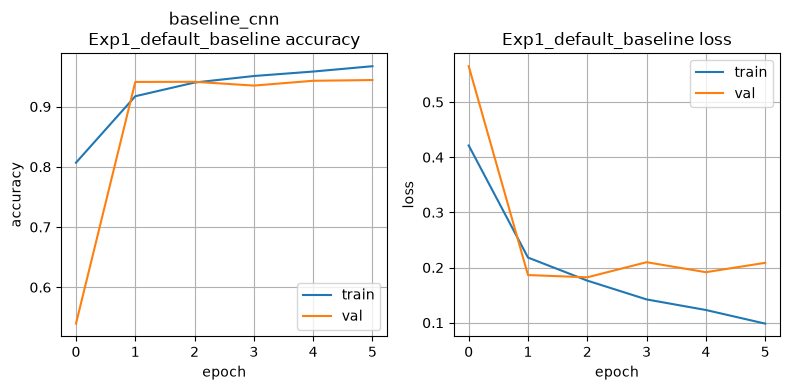

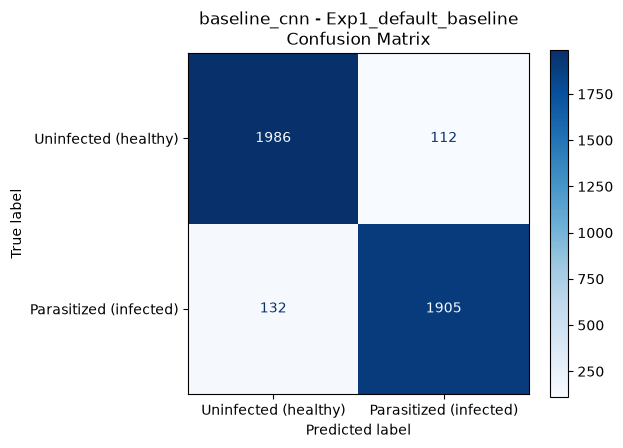

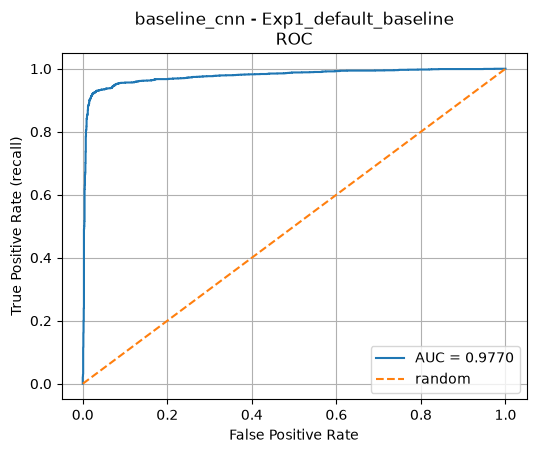


[baseline_cnn] Exp2_lower_learning_rate
{'name': 'Exp2_lower_learning_rate', 'lr': 0.0001, 'batch_size': 32, 'dropout': 0.3, 'dense_units': 128, 'augmentation': False, 'epochs': 10}
Epoch 1/10


/Users/manziivan453icloud.com/Downloads/Projects/IVAN/ML formative /.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


603/603 - 113s - 187ms/step - accuracy: 0.6435 - auc: 0.7032 - loss: 0.6293 - precision: 0.6470 - recall: 0.6314 - val_accuracy: 0.6917 - val_auc: 0.7657 - val_loss: 0.5819 - val_precision: 0.6868 - val_recall: 0.7215
Epoch 2/10
603/603 - 116s - 193ms/step - accuracy: 0.7261 - auc: 0.7987 - loss: 0.5527 - precision: 0.7272 - recall: 0.7237 - val_accuracy: 0.7428 - val_auc: 0.8234 - val_loss: 0.5267 - val_precision: 0.7230 - val_recall: 0.7992
Epoch 3/10
603/603 - 110s - 182ms/step - accuracy: 0.7960 - auc: 0.8747 - loss: 0.4601 - precision: 0.7911 - recall: 0.8043 - val_accuracy: 0.8060 - val_auc: 0.9154 - val_loss: 0.4078 - val_precision: 0.8611 - val_recall: 0.7363
Epoch 4/10
603/603 - 109s - 180ms/step - accuracy: 0.8638 - auc: 0.9373 - loss: 0.3404 - precision: 0.8517 - recall: 0.8810 - val_accuracy: 0.8819 - val_auc: 0.9513 - val_loss: 0.2958 - val_precision: 0.8512 - val_recall: 0.9299
Epoch 5/10
603/603 - 107s - 177ms/step - accuracy: 0.8940 - auc: 0.9596 - loss: 0.2688 - precis

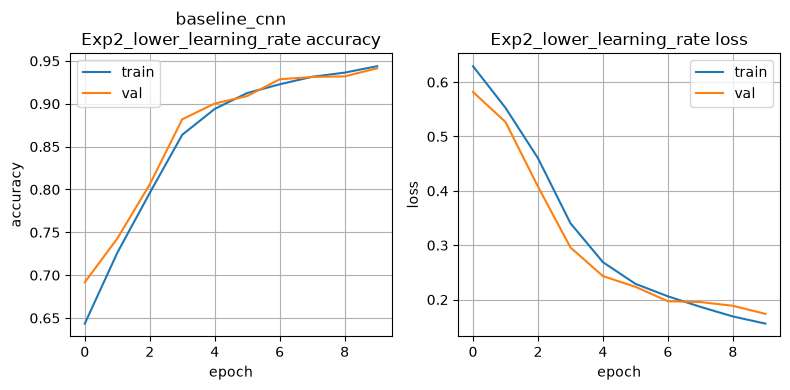

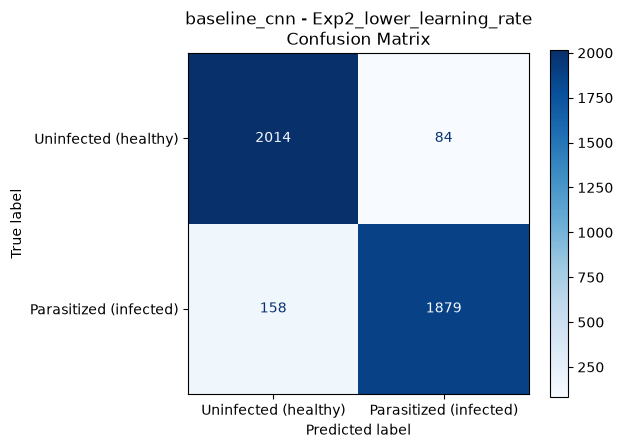

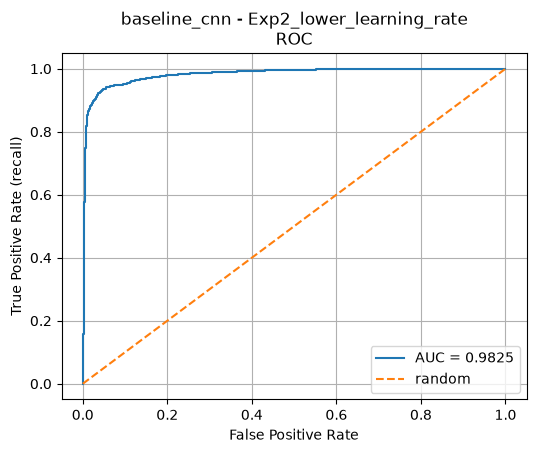


[baseline_cnn] Exp3_higher_dropout
{'name': 'Exp3_higher_dropout', 'lr': 0.001, 'batch_size': 32, 'dropout': 0.5, 'dense_units': 128, 'augmentation': False, 'epochs': 10}
Epoch 1/10


/Users/manziivan453icloud.com/Downloads/Projects/IVAN/ML formative /.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


603/603 - 107s - 178ms/step - accuracy: 0.7525 - auc: 0.8418 - loss: 0.5072 - precision: 0.7520 - recall: 0.7533 - val_accuracy: 0.9093 - val_auc: 0.9719 - val_loss: 0.2385 - val_precision: 0.8816 - val_recall: 0.9485
Epoch 2/10
603/603 - 114s - 189ms/step - accuracy: 0.9168 - auc: 0.9679 - loss: 0.2298 - precision: 0.9035 - recall: 0.9334 - val_accuracy: 0.9325 - val_auc: 0.9763 - val_loss: 0.1966 - val_precision: 0.9366 - val_recall: 0.9299
Epoch 3/10
603/603 - 107s - 177ms/step - accuracy: 0.9323 - auc: 0.9773 - loss: 0.1884 - precision: 0.9203 - recall: 0.9467 - val_accuracy: 0.9366 - val_auc: 0.9810 - val_loss: 0.1767 - val_precision: 0.9277 - val_recall: 0.9490
Epoch 4/10
603/603 - 106s - 175ms/step - accuracy: 0.9382 - auc: 0.9830 - loss: 0.1634 - precision: 0.9256 - recall: 0.9530 - val_accuracy: 0.9451 - val_auc: 0.9771 - val_loss: 0.1834 - val_precision: 0.9534 - val_recall: 0.9375
Epoch 5/10
603/603 - 139s - 230ms/step - accuracy: 0.9511 - auc: 0.9875 - loss: 0.1409 - precis

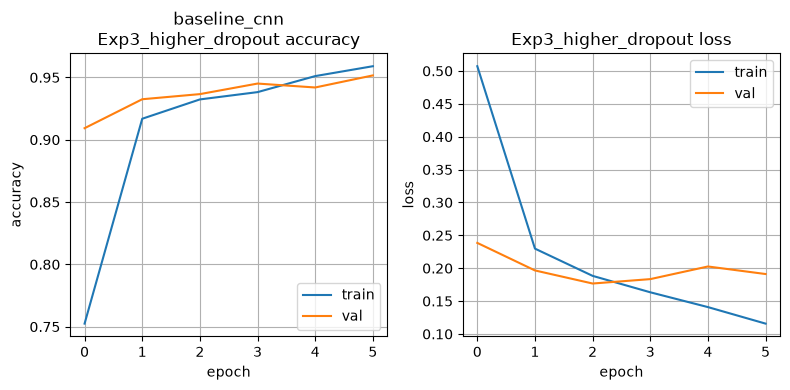

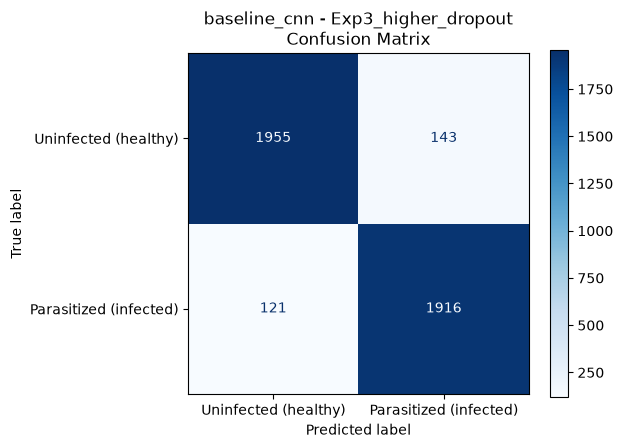

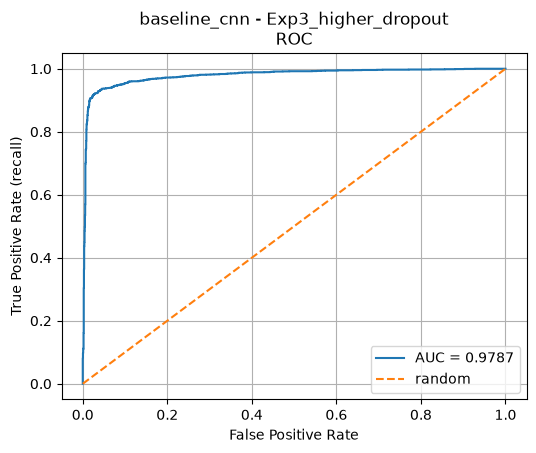


[baseline_cnn] Exp4_with_data_augmentation
{'name': 'Exp4_with_data_augmentation', 'lr': 0.001, 'batch_size': 32, 'dropout': 0.3, 'dense_units': 128, 'augmentation': True, 'epochs': 10}
Epoch 1/10


/Users/manziivan453icloud.com/Downloads/Projects/IVAN/ML formative /.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


603/603 - 115s - 191ms/step - accuracy: 0.7458 - auc: 0.8308 - loss: 0.5246 - precision: 0.7690 - recall: 0.7027 - val_accuracy: 0.8957 - val_auc: 0.9644 - val_loss: 0.2944 - val_precision: 0.9547 - val_recall: 0.8340
Epoch 2/10
603/603 - 120s - 200ms/step - accuracy: 0.9044 - auc: 0.9555 - loss: 0.2776 - precision: 0.8839 - recall: 0.9311 - val_accuracy: 0.9339 - val_auc: 0.9764 - val_loss: 0.2012 - val_precision: 0.9347 - val_recall: 0.9351
Epoch 3/10
603/603 - 120s - 199ms/step - accuracy: 0.9211 - auc: 0.9682 - loss: 0.2297 - precision: 0.9074 - recall: 0.9379 - val_accuracy: 0.9402 - val_auc: 0.9751 - val_loss: 0.2032 - val_precision: 0.9439 - val_recall: 0.9380
Epoch 4/10
603/603 - 113s - 187ms/step - accuracy: 0.9276 - auc: 0.9750 - loss: 0.1985 - precision: 0.9140 - recall: 0.9440 - val_accuracy: 0.9422 - val_auc: 0.9801 - val_loss: 0.1745 - val_precision: 0.9436 - val_recall: 0.9423
Epoch 5/10
603/603 - 114s - 188ms/step - accuracy: 0.9361 - auc: 0.9766 - loss: 0.1855 - precis

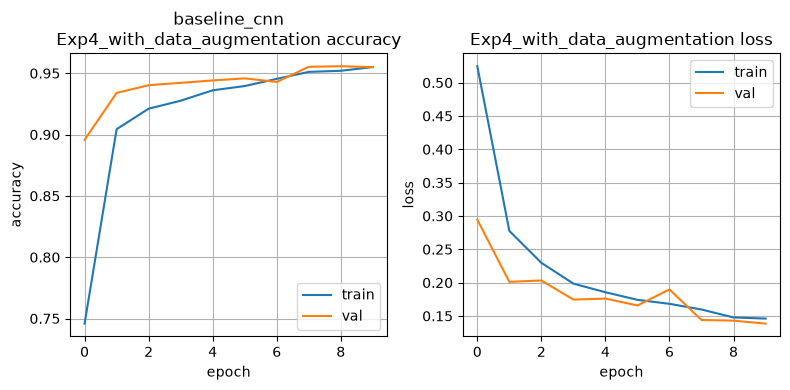

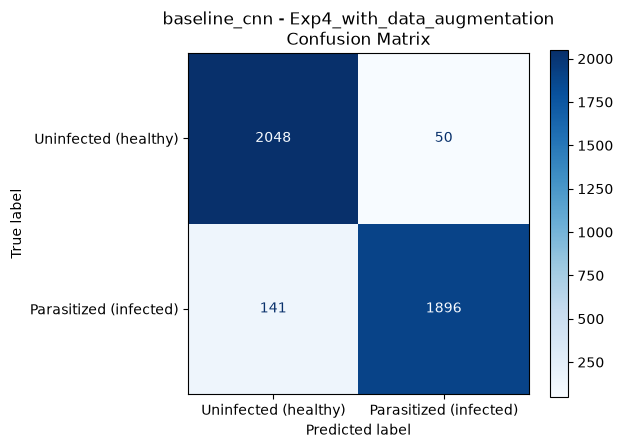

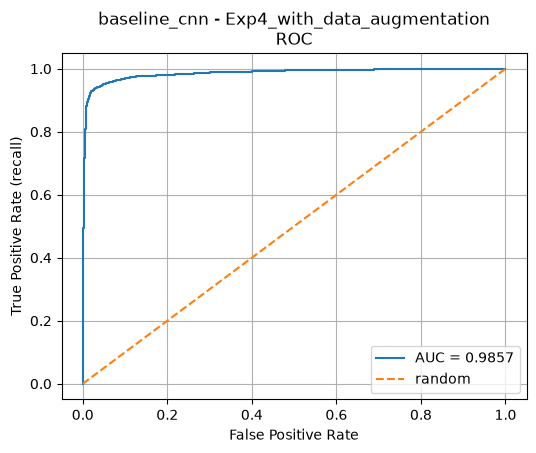


[baseline_cnn] Exp5_smaller_batch_size
{'name': 'Exp5_smaller_batch_size', 'lr': 0.001, 'batch_size': 16, 'dropout': 0.3, 'dense_units': 128, 'augmentation': False, 'epochs': 10}
Epoch 1/10


/Users/manziivan453icloud.com/Downloads/Projects/IVAN/ML formative /.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1206/1206 - 124s - 103ms/step - accuracy: 0.7700 - auc: 0.8632 - loss: 0.4677 - precision: 0.7738 - recall: 0.7631 - val_accuracy: 0.9327 - val_auc: 0.9753 - val_loss: 0.2001 - val_precision: 0.9358 - val_recall: 0.9313
Epoch 2/10
1206/1206 - 128s - 106ms/step - accuracy: 0.9253 - auc: 0.9721 - loss: 0.2104 - precision: 0.9211 - recall: 0.9304 - val_accuracy: 0.5316 - val_auc: 0.9347 - val_loss: 0.5189 - val_precision: 0.5203 - val_recall: 0.9857
Epoch 3/10
1206/1206 - 126s - 104ms/step - accuracy: 0.9360 - auc: 0.9802 - loss: 0.1747 - precision: 0.9353 - recall: 0.9368 - val_accuracy: 0.9412 - val_auc: 0.9816 - val_loss: 0.1752 - val_precision: 0.9324 - val_recall: 0.9533
Epoch 4/10
1206/1206 - 125s - 103ms/step - accuracy: 0.9529 - auc: 0.9881 - loss: 0.1328 - precision: 0.9571 - recall: 0.9484 - val_accuracy: 0.9412 - val_auc: 0.9771 - val_loss: 0.1827 - val_precision: 0.9531 - val_recall: 0.9299
Epoch 5/10
1206/1206 - 148s - 123ms/step - accuracy: 0.9619 - auc: 0.9922 - loss: 0.107

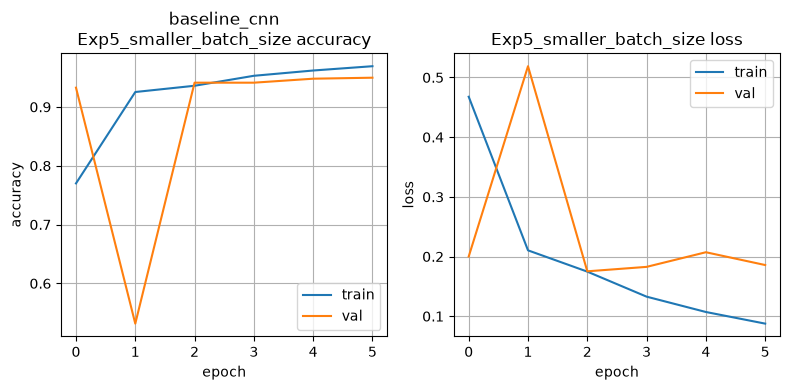

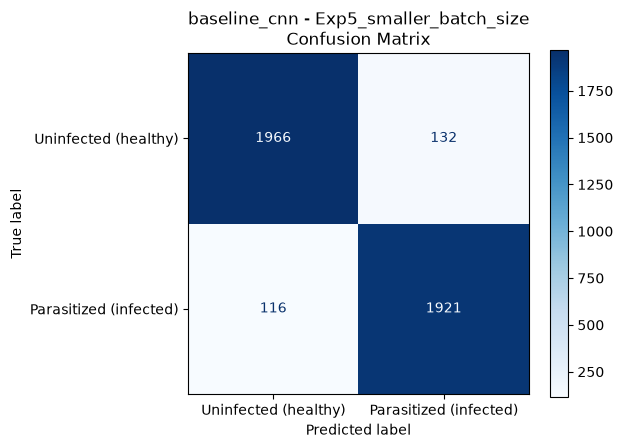

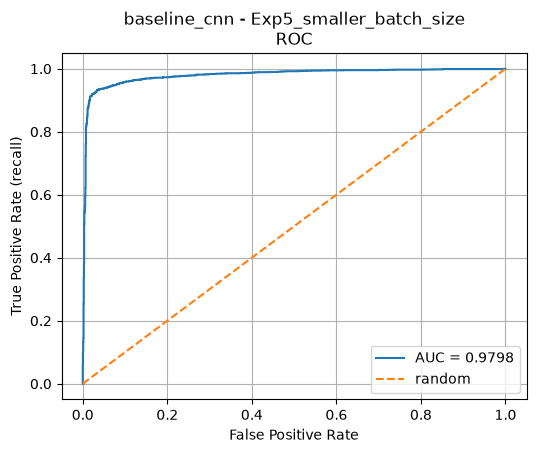


[baseline_cnn] Exp6_larger_dense_layer
{'name': 'Exp6_larger_dense_layer', 'lr': 0.001, 'batch_size': 32, 'dropout': 0.3, 'dense_units': 256, 'augmentation': False, 'epochs': 10}
Epoch 1/10


/Users/manziivan453icloud.com/Downloads/Projects/IVAN/ML formative /.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


603/603 - 126s - 209ms/step - accuracy: 0.7016 - auc: 0.7843 - loss: 0.5701 - precision: 0.7022 - recall: 0.7003 - val_accuracy: 0.9163 - val_auc: 0.9650 - val_loss: 0.2566 - val_precision: 0.9163 - val_recall: 0.9189
Epoch 2/10
603/603 - 121s - 201ms/step - accuracy: 0.9186 - auc: 0.9651 - loss: 0.2344 - precision: 0.9244 - recall: 0.9117 - val_accuracy: 0.9289 - val_auc: 0.9679 - val_loss: 0.2131 - val_precision: 0.9478 - val_recall: 0.9099
Epoch 3/10
603/603 - 120s - 198ms/step - accuracy: 0.9328 - auc: 0.9758 - loss: 0.1930 - precision: 0.9363 - recall: 0.9289 - val_accuracy: 0.9429 - val_auc: 0.9781 - val_loss: 0.1903 - val_precision: 0.9437 - val_recall: 0.9437
Epoch 4/10
603/603 - 126s - 209ms/step - accuracy: 0.9507 - auc: 0.9847 - loss: 0.1495 - precision: 0.9551 - recall: 0.9459 - val_accuracy: 0.9383 - val_auc: 0.9759 - val_loss: 0.1934 - val_precision: 0.9292 - val_recall: 0.9509
Epoch 5/10
603/603 - 124s - 205ms/step - accuracy: 0.9584 - auc: 0.9898 - loss: 0.1211 - precis

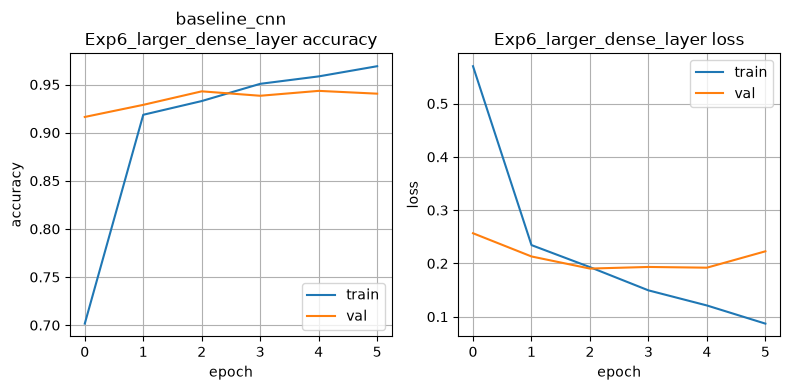

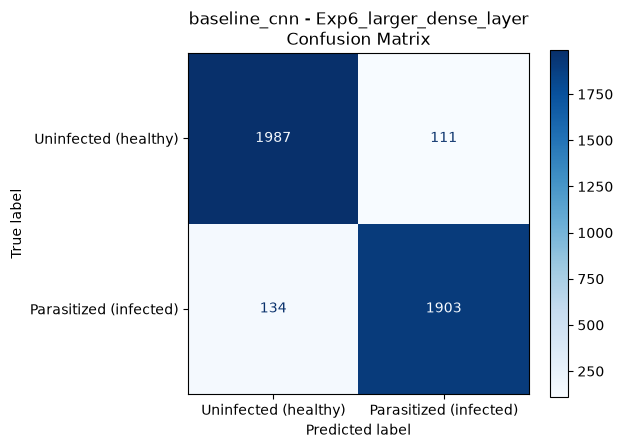

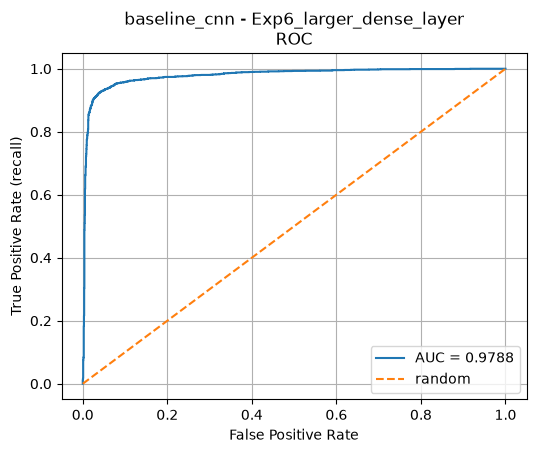


[baseline_cnn] Exp7_combined_aug_dropout
{'name': 'Exp7_combined_aug_dropout', 'lr': 0.0001, 'batch_size': 32, 'dropout': 0.5, 'dense_units': 256, 'augmentation': True, 'epochs': 12}
Epoch 1/12


/Users/manziivan453icloud.com/Downloads/Projects/IVAN/ML formative /.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


603/603 - 133s - 221ms/step - accuracy: 0.6297 - auc: 0.6769 - loss: 0.6443 - precision: 0.6352 - recall: 0.6092 - val_accuracy: 0.6647 - val_auc: 0.7349 - val_loss: 0.6080 - val_precision: 0.6644 - val_recall: 0.6853
Epoch 2/12
603/603 - 134s - 222ms/step - accuracy: 0.6966 - auc: 0.7635 - loss: 0.5875 - precision: 0.7049 - recall: 0.6764 - val_accuracy: 0.6939 - val_auc: 0.8021 - val_loss: 0.6004 - val_precision: 0.6406 - val_recall: 0.9037
Epoch 3/12
603/603 - 128s - 212ms/step - accuracy: 0.7447 - auc: 0.8173 - loss: 0.5336 - precision: 0.7521 - recall: 0.7300 - val_accuracy: 0.7820 - val_auc: 0.8666 - val_loss: 0.4841 - val_precision: 0.7972 - val_recall: 0.7649
Epoch 4/12
603/603 - 150s - 249ms/step - accuracy: 0.8081 - auc: 0.8845 - loss: 0.4479 - precision: 0.8167 - recall: 0.7946 - val_accuracy: 0.8459 - val_auc: 0.9328 - val_loss: 0.4111 - val_precision: 0.7920 - val_recall: 0.9442
Epoch 5/12
603/603 - 128s - 213ms/step - accuracy: 0.8623 - auc: 0.9331 - loss: 0.3525 - precis

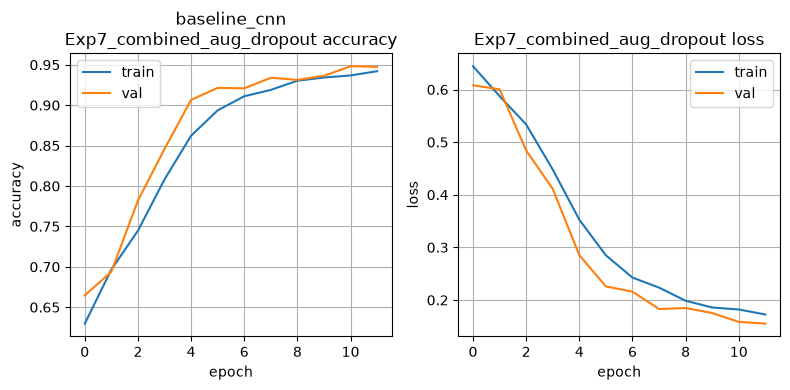

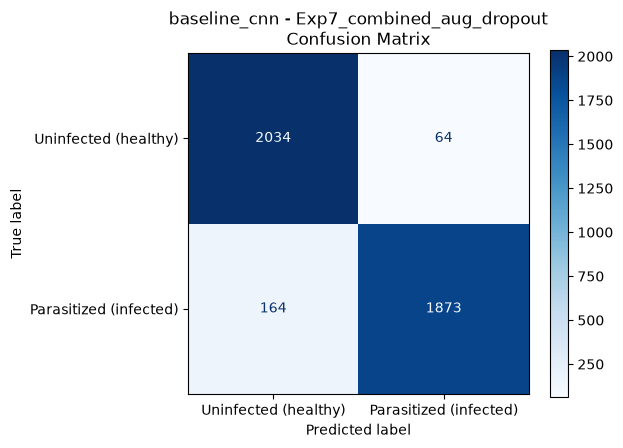

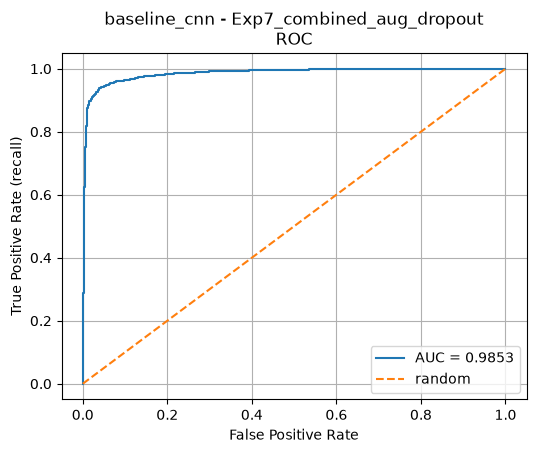


Done baseline_cnn:


,model,experiment,learning_rate,batch_size,dropout,augmentation,fine_tune,accuracy,precision,recall,f1_score,roc_auc
0,baseline_cnn,Exp1_default_baseline,0.0010,32,0.3,False,False,0.940992,0.944472,0.935199,0.939813,0.976991
1,baseline_cnn,Exp2_lower_learning_rate,0.0001,32,0.3,False,False,0.941475,0.957208,0.922435,0.939500,0.982450
2,baseline_cnn,Exp3_higher_dropout,0.0010,32,0.5,False,False,0.936155,0.930549,0.940599,0.935547,0.978743
3,baseline_cnn,Exp4_with_data_augmentation,0.0010,32,0.3,True,False,0.953809,0.974306,0.930781,0.952046,0.985749
4,baseline_cnn,Exp5_smaller_batch_size,0.0010,16,0.3,False,False,0.940024,0.935704,0.943054,0.939364,0.979813
5,baseline_cnn,Exp6_larger_dense_layer,0.0010,32,0.3,False,False,0.940750,0.944886,0.934217,0.939521,0.978845
6,baseline_cnn,Exp7_combined_aug_dropout,0.0001,32,0.5,True,False,0.944861,0.966959,0.919489,0.942627,0.985261


In [16]:
# --- Model 1: baseline_cnn (CNN from scratch) ---
free_memory()
df_baseline_cnn = run_scratch_model("baseline_cnn")
print("\nDone baseline_cnn:")
display(df_baseline_cnn)